In [ ]:
import pandas as pd

# Load CSV file (change name if you uploaded a different one)
df = pd.read_csv("/content/FAOSTAT_data_en_5-23-2025.csv")

# View columns and first few rows
print(df.columns.tolist())
df.head()


['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2012,2012,kg/ha,774.6,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2013,2013,kg/ha,784.0,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2014,2014,kg/ha,790.9,E,Estimated value,NaN
3,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2015,2015,kg/ha,799.4,E,Estimated value,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2016,2016,kg/ha,714.9,A,Official figure,NaN


In [ ]:
# Drop irrelevant columns (if present)
columns_to_drop = ["Domain Code", "Area Code", "Element Code", "Item Code", "Flag", "Flag Description"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Strip whitespace and replace spaces in column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Filter for India (assuming no state-wise split in FAOSTAT)
df = df[df["Area"] == "India"]

# Remove rows with non-positive values
df = df[df["Value"] > 0]

df.head()


,Domain,Area_Code_(M49),Area,Element,Item_Code_(CPC),Item,Year_Code,Year,Unit,Value,Note
0,Crops and livestock products,356,India,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2012,2012,kg/ha,774.6,NaN
1,Crops and livestock products,356,India,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2013,2013,kg/ha,784.0,NaN
2,Crops and livestock products,356,India,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2014,2014,kg/ha,790.9,NaN
3,Crops and livestock products,356,India,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2015,2015,kg/ha,799.4,NaN
4,Crops and livestock products,356,India,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2016,2016,kg/ha,714.9,NaN


In [ ]:
# Pivot Element to columns: Yield, Production, Area harvested
df_pivot = df.pivot_table(
    values="Value",
    index=["Year", "Item"],
    columns="Element",
    aggfunc="mean"
).reset_index()

# Flatten multi-index
df_pivot.columns.name = None
df_pivot = df_pivot.rename(columns={
    "Item": "Crop",
    "Area harvested": "Area_harvested",
    "Yield": "Yield",
    "Production": "Production"
})

df_pivot.head()


,Year,Crop,Yield
0,2012,"Anise, badian, coriander, cumin, caraway, fenn...",774.6
1,2012,Apples,6845.0
2,2012,Apricots,2829.9
3,2012,Areca nuts,1467.7
4,2012,Bananas,34161.1


In [ ]:
# Sort by Crop and Year for proper lagging
df_pivot = df_pivot.sort_values(by=["Crop", "Year"])

# Create a lag feature: previous year's yield
df_pivot["Yield_Lag_1"] = df_pivot.groupby("Crop")["Yield"].shift(1)

# Drop rows with missing lag values
df_model = df_pivot.dropna()

# Check result
df_model.head()


,Year,Crop,Yield,Yield_Lag_1
81,2013,"Anise, badian, coriander, cumin, caraway, fenn...",784.0,774.6
162,2014,"Anise, badian, coriander, cumin, caraway, fenn...",790.9,784.0
243,2015,"Anise, badian, coriander, cumin, caraway, fenn...",799.4,790.9
324,2016,"Anise, badian, coriander, cumin, caraway, fenn...",714.9,799.4
405,2017,"Anise, badian, coriander, cumin, caraway, fenn...",989.0,714.9


In [ ]:
df["Element"].unique()


array(['Yield'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode the crop names into numbers
le = LabelEncoder()
df_model["Crop_Encoded"] = le.fit_transform(df_model["Crop"])

# Check the mapping (optional)
crop_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Crop Encoding:", crop_mapping)


Crop Encoding: {'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw': np.int64(0), 'Apples': np.int64(1), 'Apricots': np.int64(2), 'Areca nuts': np.int64(3), 'Bananas': np.int64(4), 'Barley': np.int64(5), 'Beans, dry': np.int64(6), 'Cabbages': np.int64(7), 'Cantaloupes and other melons': np.int64(8), 'Carrots and turnips': np.int64(9), 'Cashew nuts, in shell': np.int64(10), 'Cassava, fresh': np.int64(11), 'Castor oil seeds': np.int64(12), 'Cauliflowers and broccoli': np.int64(13), 'Cherries': np.int64(14), 'Chick peas, dry': np.int64(15), 'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw': np.int64(16), 'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)': np.int64(17), 'Cocoa beans': np.int64(18), 'Coconuts, in shell': np.int64(19), 'Coffee, green': np.int64(20), 'Cucumbers and gherkins': np.int64(21), 'Eggplants (aubergines)': np.int64(22), 'Figs': np.int64(23), 'Ginger, raw': np.int64(24), 'Grapes': np.int64(25), 'Green garlic': np.int64(

<ipython-input-12-4c05ac7476cf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["Crop_Encoded"] = le.fit_transform(df_model["Crop"])


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
features = ["Year", "Yield_Lag_1", "Crop_Encoded"]
X = df_model[features]
y = df_model["Yield"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R² Score: 0.9939389505294459
MSE: 918937.5784118996


In [ ]:
# Predict for Rice in 2025 (example)
crop_name = "Rice"
if crop_name in le.classes_:
    crop_code = le.transform([crop_name])[0]

    sample_input = pd.DataFrame([{
        "Year": 2025,
        "Yield_Lag_1": 2.3,  # replace with actual 2024 yield if available
        "Crop_Encoded": crop_code
    }])

    predicted_yield = model.predict(sample_input)[0]
    print(f"Predicted yield for {crop_name} in 2025: {predicted_yield:.2f} tonnes/hectare")
else:
    print(f"{crop_name} not found in the dataset.")


Predicted yield for Rice in 2025: 302.41 tonnes/hectare


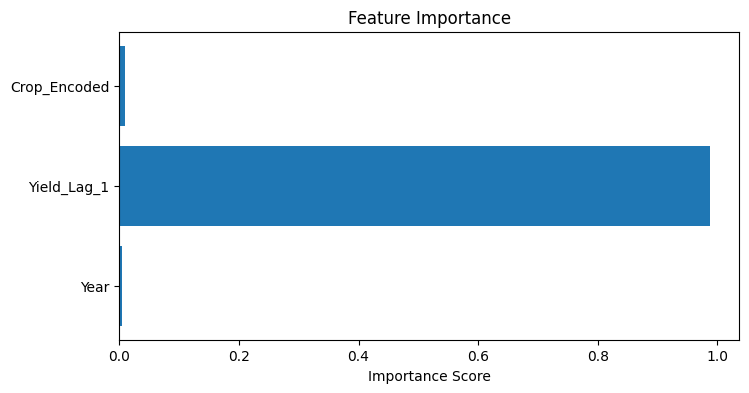

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()
